In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [20]:
df = pd.read_excel('Tudo Gostoso_v2.xlsx', 
                   sheet_name='Books combined',nrows=84
)

carbon_100g = pd.to_numeric(df['CF (gCO2e) per 100 grams'], errors='coerce')
calories_per_carbon = pd.to_numeric(df['CF (gCO2e) per calorie'], errors='coerce')
protein_per_carbon = pd.to_numeric(df['CF (gCO2e) per protein'], errors='coerce')
carbon_per_servings = pd.to_numeric(df['CF (gCO2e) per serving'], errors='coerce')

In [3]:
df_radar = df[[
'Title (Eng)',
'Type B',
'CF (gCO2e) per 100 grams', 
'CF (gCO2e) per calorie',
'CF (gCO2e) per protein',
'CF (gCO2e) per serving'
]].copy()

In [4]:
scaler = MinMaxScaler()
cols = ['CF (gCO2e) per 100 grams', 
'CF (gCO2e) per calorie',
'CF (gCO2e) per protein',
'CF (gCO2e) per serving']

df_radar[cols] = scaler.fit_transform(df_radar[cols])

In [5]:
df_radar

,Title (Eng),Type B,CF (gCO2e) per 100 grams,CF (gCO2e) per calorie,CF (gCO2e) per protein,CF (gCO2e) per serving
0,Oxtail stew with watercress,Beef,0.649200,0.357591,0.494704,0.821688
1,Fillet steak with crunchy garlic topping,Beef,0.966998,0.524884,0.396532,1.000000
2,Beef stew,Beef,0.436471,0.358706,0.219005,0.509875
3,Beef jerky and pumpkin,Beef,0.505221,0.671962,0.526005,0.289514
4,Beef jerky risotto,Beef,0.685540,0.269180,0.362066,0.252583
...,...,...,...,...,...,...
78,Corn casserole,Vegetarian,0.112295,0.108767,0.130137,0.033625
79,Mashed butternut squash,Vegetarian,0.116517,0.249707,1.000000,0.044213
80,Fresh corn puree,Vegetarian,0.060198,0.085908,0.091495,0.027276
81,Fried tapioca dice with chile pepper jam,Vegetarian,0.101738,0.073639,0.134729,0.094749


'''Recipes with highest CF:
Oven-roasted picanha with garlic butter
Black bean and pork stew
Chicken and palm hearts pie
Leão Veloso fish soup
Vegetarian moqueca
Fried tapioca dice with chile pepper jam 


In [35]:
selected = df_radar[df_radar['Title (Eng)'].isin([
    'Oven-roasted picanha with garlic butter',
    'Black bean and pork stew',
    'Chicken and palm hearts pie',
    'Leão Veloso fish soup',
    'Vegetarian moqueca',
    'Fried tapioca dice with chile pepper jam '
])]

In [36]:
categories = ['CF (gCO2e) per 100 grams', 
'CF (gCO2e) per calorie',
'CF (gCO2e) per protein',
'CF (gCO2e) per serving']

In [ ]:
selected.drop(columns="Title (Eng)")

,Type B,CF (gCO2e) per 100 grams,CF (gCO2e) per calorie,CF (gCO2e) per protein,CF (gCO2e) per serving
10,Beef,0.553413,0.553914,0.374837,0.514400
21,Pork,0.236599,0.160643,0.107353,0.154081
34,Poultry,0.154924,0.086836,0.107309,0.167386
51,Sea food,0.140898,0.421099,0.123237,0.163902
57,Vegan,0.076924,0.066111,0.092483,0.086841
81,Vegetarian,0.101738,0.073639,0.134729,0.094749


In [46]:
selected_transposed = selected.drop(columns="Title (Eng)")
selected_transposed

,Type B,CF (gCO2e) per 100 grams,CF (gCO2e) per calorie,CF (gCO2e) per protein,CF (gCO2e) per serving
10,Beef,0.553413,0.553914,0.374837,0.514400
21,Pork,0.236599,0.160643,0.107353,0.154081
34,Poultry,0.154924,0.086836,0.107309,0.167386
51,Sea food,0.140898,0.421099,0.123237,0.163902
57,Vegan,0.076924,0.066111,0.092483,0.086841
81,Vegetarian,0.101738,0.073639,0.134729,0.094749


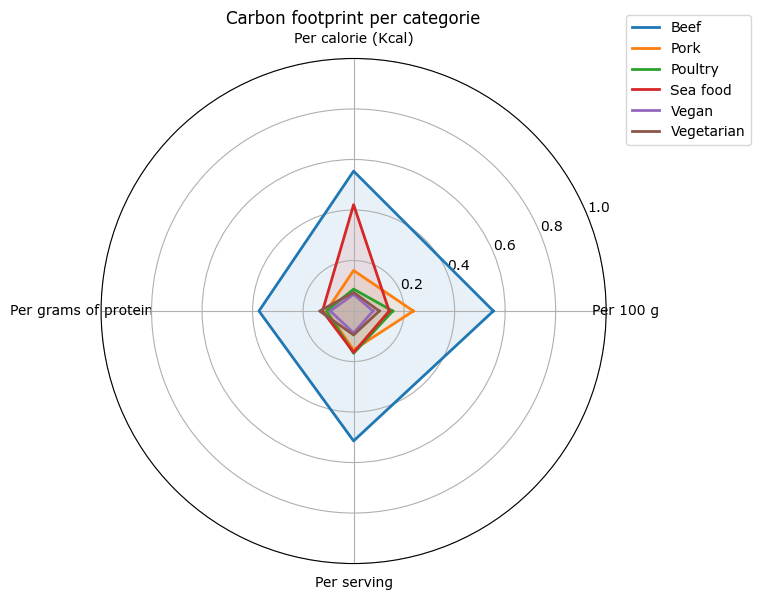

In [60]:
# métricas do radar
categories = [
    'CF (gCO2e) per 100 grams',
    'CF (gCO2e) per calorie',
    'CF (gCO2e) per protein',
    'CF (gCO2e) per serving'
]

# número de eixos
N = len(categories)

# ângulos
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

# fechar círculo
angles += angles[:1]

# figura
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# plotar cada categoria
for _, row in selected.iterrows():

    values = row[categories].tolist()

    # fechar radar
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row['Type B']
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

# labels dos eixos
ax.set_xticks(angles[:-1])

ax.set_xticklabels([
    'Per 100 g',
    'Per calorie (Kcal)',
    'Per grams of protein',
    'Per serving'
])

# escala
ax.set_ylim(0,1)

# legenda
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.title('Carbon footprint per categorie')
plt.tight_layout()

plt.show()

Now, analyzing the recipes with lowest CF

In [21]:
selected_check = df_radar[df_radar['Title (Eng)'].isin([
    'Brazilian rice with black-eyed peas, beef and cheese'])]
selected_check

,Title (Eng),Type B,CF (gCO2e) per 100 grams,CF (gCO2e) per calorie,CF (gCO2e) per protein,CF (gCO2e) per serving


In [ ]:
selected_l = df_radar[df_radar['Title (Eng)'].isin([
    'Brazilian rice with black-eyed peas, beef and cheese',
    'Pork chops, Minas-style',
    'Deep-fried polenta',
    'Sautéed shrimp with garlic',
    'Deep-fried straw potatoes',
    'deep-fried pastry with cheese filling'
])]

In [13]:
categories = ['CF (gCO2e) per 100 grams', 
'CF (gCO2e) per calorie',
'CF (gCO2e) per protein',
'CF (gCO2e) per serving']

In [ ]:
selected_l.drop(columns="Title (Eng)")
selected_transposed = selected_l.drop(columns="Title (Eng)")
selected_transposed


,Type B,CF (gCO2e) per 100 grams,CF (gCO2e) per calorie,CF (gCO2e) per protein,CF (gCO2e) per serving
20,Pork,0.190996,0.216344,0.087183,0.083293
40,Poultry,0.016483,0.030504,0.065276,0.023039
44,Sea food,0.161448,0.220753,0.164581,0.053599
64,Vegan,0.006512,0.012419,0.106701,0.005661
71,Vegetarian,0.007717,0.003353,0.000000,0.006744


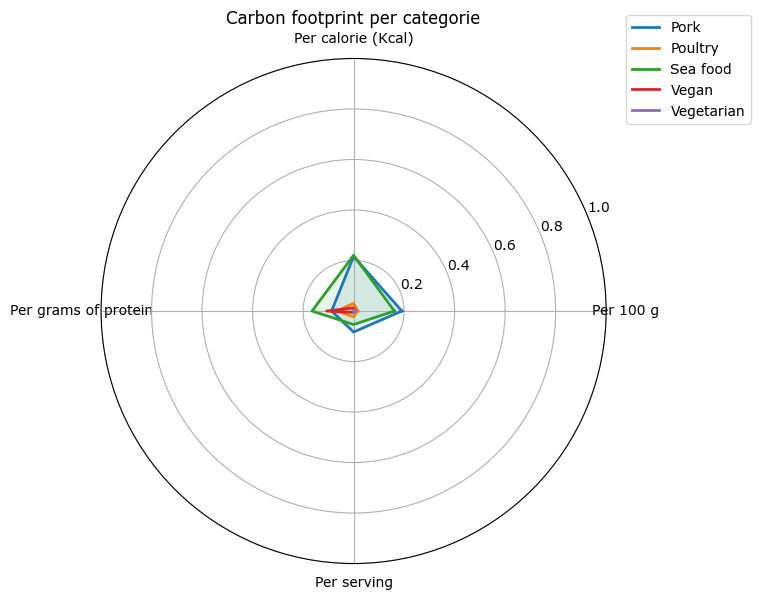

In [10]:
# métricas do radar
categories = [
    'CF (gCO2e) per 100 grams',
    'CF (gCO2e) per calorie',
    'CF (gCO2e) per protein',
    'CF (gCO2e) per serving'
]

# número de eixos
N = len(categories)

# ângulos
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

# fechar círculo
angles += angles[:1]

# figura
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# plotar cada categoria
for _, row in selected_l.iterrows():

    values = row[categories].tolist()

    # fechar radar
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row['Type B']
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

# labels dos eixos
ax.set_xticks(angles[:-1])

ax.set_xticklabels([
    'Per 100 g',
    'Per calorie (Kcal)',
    'Per grams of protein',
    'Per serving'
])

# escala
ax.set_ylim(0,1)

# legenda
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))

plt.title('Carbon footprint per categorie')
plt.tight_layout()

plt.show()